In [19]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [20]:
df = pd.read_csv("Online Sales Data.csv")

print("Dataset shape:", df.shape)

print("\nColumns:")

print(df.columns.tolist())

print("\nFirst 5 rows:")

display(df.head())

Dataset shape: (240, 9)

Columns:
['Transaction ID', 'Date', 'Product Category', 'Product Name', 'Units Sold', 'Unit Price', 'Total Revenue', 'Region', 'Payment Method']

First 5 rows:


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [21]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic statistics:")
display(df.describe(include="all").T)

Data types:


Transaction ID        int64
Date                 object
Product Category     object
Product Name         object
Units Sold            int64
Unit Price          float64
Total Revenue       float64
Region               object
Payment Method       object
dtype: object


Missing values:


Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64


Duplicate rows: 0

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction ID,240.0,NaN,NaN,NaN,10120.5,69.42622,10001.0,10060.75,10120.5,10180.25,10240.0
Date,240,240,2024-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Category,240,6,Electronics,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Name,240,232,Dyson Supersonic Hair Dryer,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Units Sold,240.0,NaN,NaN,NaN,2.158333,1.322454,1.0,1.0,2.0,3.0,10.0
Unit Price,240.0,NaN,NaN,NaN,236.395583,429.446695,6.5,29.5,89.99,249.99,3899.99
Total Revenue,240.0,NaN,NaN,NaN,335.699375,485.804469,6.5,62.965,179.97,399.225,3899.99
Region,240,3,North America,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment Method,240,3,Credit Card,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.drop_duplicates().copy()

required_columns = [
    "Date",
    "Product Category",
    "Product Name",
    "Units Sold",
    "Unit Price",
    "Region",
    "Payment Method"
]

df = df.dropna(subset=required_columns).copy()

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["DayOfYear"] = df["Date"].dt.dayofyear
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (240, 15)


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card,2024,1,1,0,1,1
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal,2024,1,2,1,2,1
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card,2024,1,3,2,3,1
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card,2024,1,4,3,4,1
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal,2024,1,5,4,5,1


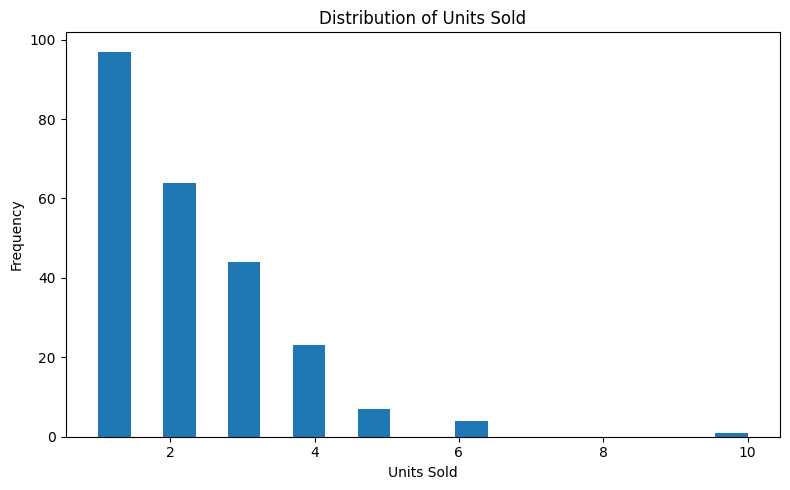

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["Units Sold"], bins=20)

plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.title("Distribution of Units Sold")

plt.tight_layout()
plt.show()

In [33]:
# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

# Define features and target
target = "Units Sold"

features = [
    "Unit Price",
    "Product Category",
    "Product Name",
    "Region",
    "Payment Method",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "WeekOfYear"
]

X = df[features]
y = df[target]

# Chronological 80/20 split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(df["Date"].iloc[0], "to", df["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["Date"].iloc[split_index], "to", df["Date"].iloc[-1])

Training observations: 192
Testing observations: 48

Training period:
2024-01-01 00:00:00 to 2024-07-10 00:00:00

Testing period:
2024-07-11 00:00:00 to 2024-08-27 00:00:00


In [24]:
'''# ============================================
# REFINED FEATURE SET
# ============================================

target = "Units Sold"

features = [
    "Unit Price",
    "Product Category",
    "Region",
    "Year",
    "Month",
    "DayOfWeek",
    "DayOfYear",
    "WeekOfYear"
]

X = df[features]
y = df[target]

# Chronological 80/20 split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(df["Date"].iloc[0], "to", df["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["Date"].iloc[split_index], "to", df["Date"].iloc[-1])'''

Training observations: 192
Testing observations: 48

Training period:
2024-01-01 00:00:00 to 2024-07-10 00:00:00

Testing period:
2024-07-11 00:00:00 to 2024-08-27 00:00:00


In [34]:
categorical_features = [
    "Product Category",
    "Product Name",
    "Region",
    "Payment Method"
]

numeric_features = [
    "Unit Price",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "WeekOfYear"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [25]:
'''# ============================================
# PREPROCESSING FOR REFINED MODEL
# ============================================

categorical_features = [
    "Product Category",
    "Region"
]

numeric_features = [
    "Unit Price",
    "Year",
    "Month",
    "DayOfWeek",
    "DayOfYear",
    "WeekOfYear"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor updated successfully.")'''

Preprocessor updated successfully.


In [35]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [36]:
# Predictions
y_pred = rf_pipeline.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("======================================")
print("RANDOM FOREST RESULTS - ONLINE SALES")
print("======================================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

RANDOM FOREST RESULTS - ONLINE SALES
MAE  : 0.4081
RMSE : 0.5310
R²   : 0.6772


In [27]:
'''y_pred = rf_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("======================================")
print("REFINED RANDOM FOREST RESULTS")
print("======================================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")'''

REFINED RANDOM FOREST RESULTS
MAE  : 0.4900
RMSE : 0.7352
R²   : 0.3810


In [28]:
results_online = pd.DataFrame({
    "Date": df.iloc[split_index:]["Date"].values,
    "Actual Units Sold": y_test.values,
    "Predicted Units Sold": y_pred
})

display(results_online.head(10))

,Date,Actual Units Sold,Predicted Units Sold
0,2024-07-11,1,1.250
1,2024-07-12,1,1.676
2,2024-07-13,2,1.894
3,2024-07-14,2,2.570
4,2024-07-15,1,1.212
5,2024-07-16,1,1.118
6,2024-07-17,2,1.198
7,2024-07-18,1,1.564
8,2024-07-19,3,3.324
9,2024-07-20,2,3.082


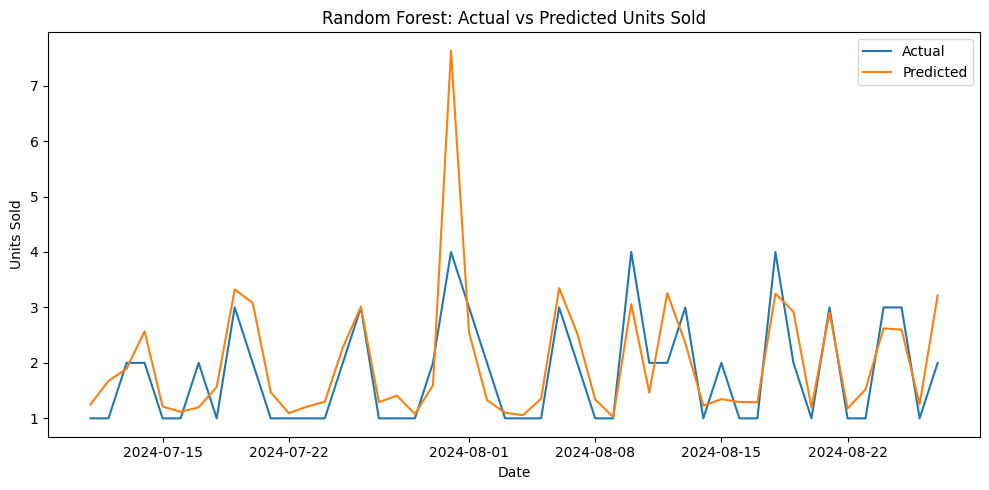

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_online["Date"],
    results_online["Actual Units Sold"],
    label="Actual"
)

plt.plot(
    results_online["Date"],
    results_online["Predicted Units Sold"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Random Forest: Actual vs Predicted Units Sold")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

,Feature,Importance
9,numeric__Unit Price,0.397226
2,categorical__Product Category_Clothing,0.151656
7,categorical__Region_Europe,0.130840
13,numeric__DayOfYear,0.069901
12,numeric__DayOfWeek,0.063481
14,numeric__WeekOfYear,0.044004
1,categorical__Product Category_Books,0.039900
6,categorical__Region_Asia,0.035128
0,categorical__Product Category_Beauty Products,0.025397
11,numeric__Month,0.017999


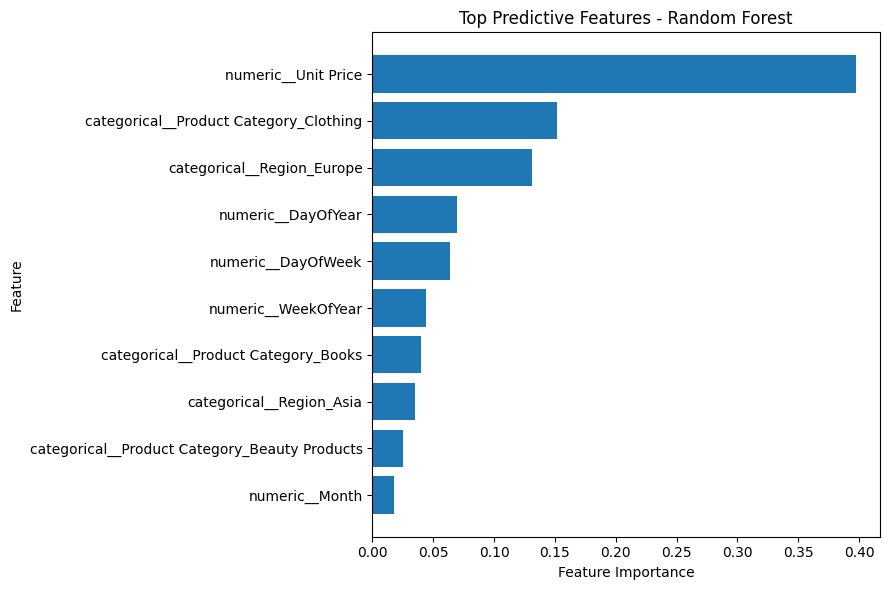

In [31]:
top_features = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Predictive Features - Random Forest")

plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Original feature set
features_original = [
    "Unit Price",
    "Product Category",
    "Product Name",
    "Region",
    "Payment Method",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "WeekOfYear"
]

X_original = df[features_original]
y_original = df["Units Sold"]

categorical_original = [
    "Product Category",
    "Product Name",
    "Region",
    "Payment Method"
]

numeric_original = [
    "Unit Price",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "WeekOfYear"
]

preprocessor_original = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_original
        ),
        (
            "numeric",
            "passthrough",
            numeric_original
        )
    ]
)

rf_original = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_original),
        ("model", rf_original)
    ]
)

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

cv_r2 = cross_val_score(
    rf_cv_pipeline,
    X_original,
    y_original,
    cv=tscv,
    scoring="r2"
)

print("Time-Series Cross-Validation R²:")
print(cv_r2)

print("\nMean CV R²:", cv_r2.mean())
print("Standard deviation:", cv_r2.std())

Time-Series Cross-Validation R²:
[0.46092861 0.40594126 0.54104749 0.74168634 0.68165993]

Mean CV R²: 0.566252727342912
Standard deviation: 0.1276902631406313
